# Event-Driven Market Reaction Backtester

Measures how Indian market indices react around key macro events:  
**Union Budget · RBI MPC · US Fed · Elections · Market Crashes · Geopolitical Events · Macro Data Surprises**

**Indices covered:** NIFTY 50 · SENSEX · BANK NIFTY · NIFTY MIDCAP 100

**Methodology:**  
For each event, we extract a ±10 trading-day window and measure:  
- Cumulative log-return relative to event day (day 0)  
- Day-0 intraday range as % of prior close  
- Post-event drift (day +1 to +5, +1 to +10)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#e6edf3',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#e6edf3',
    'grid.color': '#21262d',
    'grid.linewidth': 0.5,
    'legend.facecolor': '#161b22',
    'legend.edgecolor': '#30363d',
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

DATA_DIR = '../dataset/'
WINDOW = 10  # trading days each side

INDICES = {
    'NIFTY 50':        'NIFTY.csv',
    'SENSEX':          'SENSEX.csv',
    'BANK NIFTY':      'BANKNIFTY.csv',
    'NIFTY MIDCAP 100':'NIFTY_MIDCAP_100.csv',
}

EVENT_COLORS = {
    'BUDGET':        '#f0c040',
    'RBI_MPC':       '#58a6ff',
    'US_FED':        '#bc8cff',
    'ELECTION':      '#3fb950',
    'MARKET_CRASH':  '#f85149',
    'GEOPOLITICAL':  '#ff9500',
    'MACRO_DATA':    '#56d364',
}

INDEX_COLORS = {
    'NIFTY 50':        '#58a6ff',
    'SENSEX':          '#f0c040',
    'BANK NIFTY':      '#ff9500',
    'NIFTY MIDCAP 100':'#3fb950',
}

In [2]:
# ── Load index data ──────────────────────────────────────────────────────────
def load_index(filename):
    df = pd.read_csv(DATA_DIR + filename, parse_dates=['date'])
    df['date'] = pd.to_datetime(df['date'], utc=True).dt.tz_convert('Asia/Kolkata').dt.tz_localize(None).dt.normalize()
    df = df.sort_values('date').drop_duplicates('date').set_index('date')
    df['log_ret'] = np.log(df['close'] / df['close'].shift(1))
    df['intraday_range'] = (df['high'] - df['low']) / df['close'].shift(1) * 100
    return df

indices = {name: load_index(f) for name, f in INDICES.items()}

for name, df in indices.items():
    print(f"{name:25s}  {df.index.min().date()} → {df.index.max().date()}  ({len(df):,} trading days)")

NIFTY 50                   2000-01-03 → 2026-04-30  (6,546 trading days)
SENSEX                     2000-01-03 → 2026-04-30  (6,546 trading days)
BANK NIFTY                 2000-01-01 → 2026-04-30  (6,533 trading days)
NIFTY MIDCAP 100           2001-01-01 → 2026-04-30  (6,295 trading days)


In [3]:
# ── Load event database ──────────────────────────────────────────────────────
events = pd.read_csv('events.csv', parse_dates=['date'])
events['date'] = events['date'].dt.normalize()
events = events.sort_values('date').reset_index(drop=True)

print(f"Total events: {len(events)}")
print(events.groupby('event_type').size().sort_values(ascending=False).to_string())

Total events: 110
event_type
RBI_MPC         50
BUDGET          28
MARKET_CRASH    12
GEOPOLITICAL     7
ELECTION         5
US_FED           5
MACRO_DATA       3


In [4]:
# ── Event window extraction ───────────────────────────────────────────────────
def get_window(index_df, event_date, window=WINDOW):
    """Return aligned returns for days -window..+window around event_date.
    Returns None if the event date (or close to it) isn't in the index.
    """
    trading_days = index_df.index
    # find the nearest trading day on or after event_date
    candidates = trading_days[trading_days >= event_date]
    if len(candidates) == 0:
        return None
    event_td = candidates[0]
    # check it's within 3 calendar days (handles weekends)
    if (event_td - event_date).days > 3:
        return None
    pos = trading_days.get_loc(event_td)
    lo = pos - window
    hi = pos + window + 1
    if lo < 0 or hi > len(trading_days):
        return None
    sub = index_df.iloc[lo:hi].copy()
    sub['day_offset'] = np.arange(-window, window + 1)
    # cumulative return anchored at close of day -1
    anchor_close = index_df.iloc[pos - 1]['close']
    sub['cum_ret'] = (np.log(sub['close'] / anchor_close)) * 100
    return sub

# Build event-window records
records = []
for _, ev in events.iterrows():
    for idx_name, idx_df in indices.items():
        w = get_window(idx_df, ev['date'])
        if w is None:
            continue
        for _, row in w.iterrows():
            records.append({
                'event_date':  ev['date'],
                'event_type':  ev['event_type'],
                'label':       ev['label'],
                'index':       idx_name,
                'day_offset':  int(row['day_offset']),
                'cum_ret':     row['cum_ret'],
                'log_ret':     row['log_ret'] * 100,
                'intraday_range': row['intraday_range'],
            })

ev_df = pd.DataFrame(records)
print(f"Event-window rows: {len(ev_df):,}")
print(f"Unique events captured: {ev_df[['event_date','event_type']].drop_duplicates().shape[0]}")

Event-window rows: 9,219
Unique events captured: 110


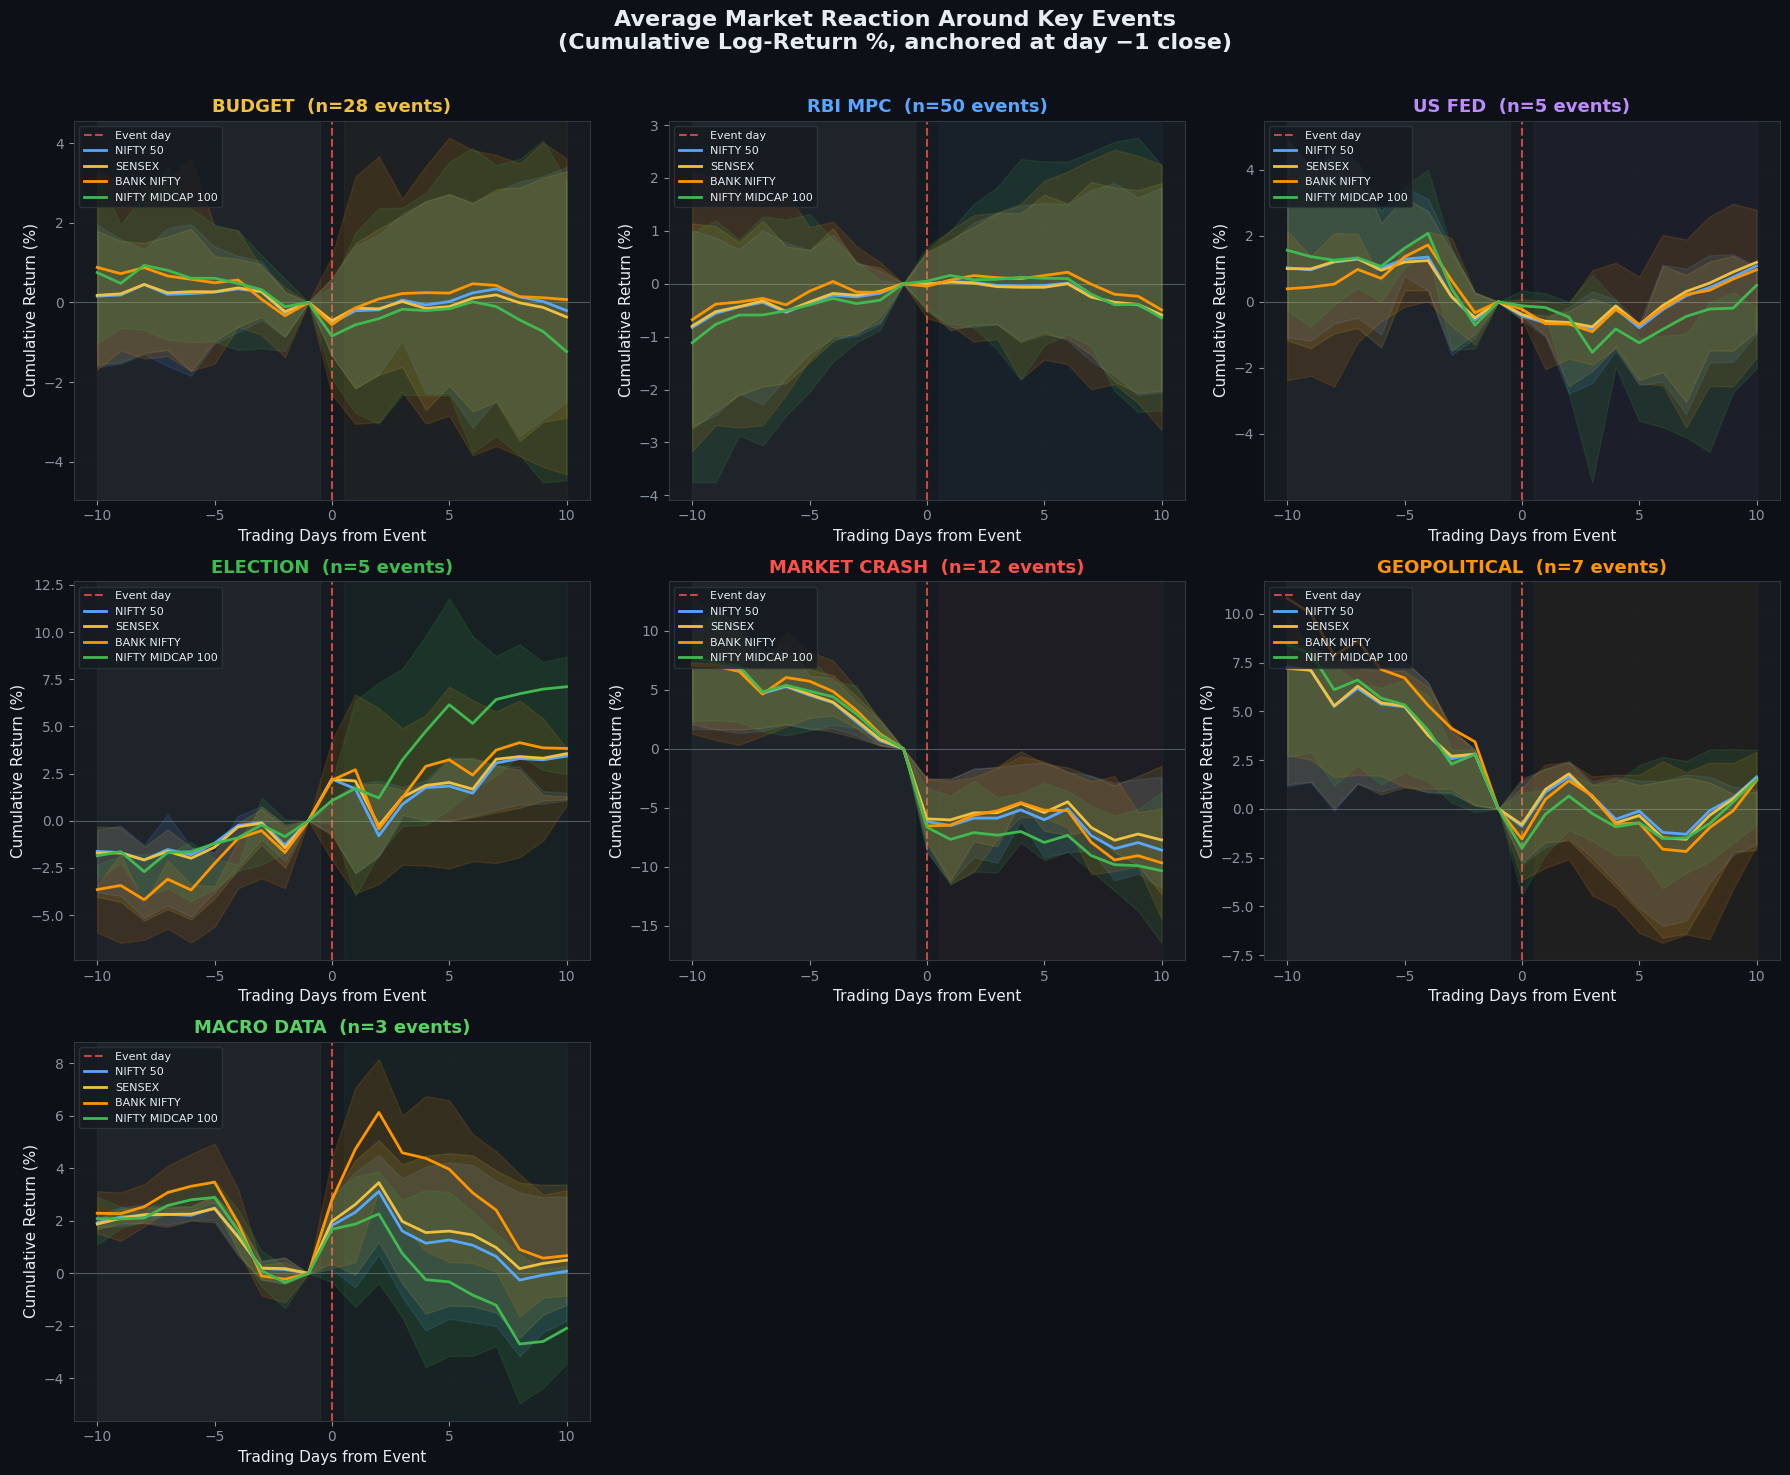

Saved: chart1_avg_cumret_fan.png


In [5]:
# ── CHART 1: Average Cumulative Return Fan Charts ────────────────────────────
event_types = list(EVENT_COLORS.keys())
n_types = len(event_types)
ncols = 3
nrows = (n_types + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
fig.suptitle('Average Market Reaction Around Key Events\n(Cumulative Log-Return %, anchored at day −1 close)',
             fontsize=16, fontweight='bold', y=0.98)
axes = axes.flatten()

offsets = np.arange(-WINDOW, WINDOW + 1)

for ax_idx, etype in enumerate(event_types):
    ax = axes[ax_idx]
    sub = ev_df[ev_df['event_type'] == etype]
    n_events = sub['event_date'].nunique()

    ax.axvline(0, color='#f85149', lw=1.5, ls='--', alpha=0.8, label='Event day')
    ax.axhline(0, color='#8b949e', lw=0.8, alpha=0.5)
    ax.axvspan(-WINDOW, -0.5, alpha=0.04, color='white')
    ax.axvspan(0.5, WINDOW, alpha=0.04, color=EVENT_COLORS[etype])

    for idx_name, idx_color in INDEX_COLORS.items():
        idx_sub = sub[sub['index'] == idx_name]
        if idx_sub.empty:
            continue
        pivot = idx_sub.groupby(['event_date', 'day_offset'])['cum_ret'].first().unstack(level=0)
        mean_ret = pivot.mean(axis=1)
        p25 = pivot.quantile(0.25, axis=1)
        p75 = pivot.quantile(0.75, axis=1)

        ax.plot(mean_ret.index, mean_ret.values, color=idx_color, lw=2,
                label=idx_name, zorder=3)
        ax.fill_between(mean_ret.index, p25.values, p75.values,
                        color=idx_color, alpha=0.12, zorder=2)

    ax.set_title(f"{etype.replace('_',' ')}  (n={n_events} events)",
                 color=EVENT_COLORS[etype], fontweight='bold')
    ax.set_xlabel('Trading Days from Event')
    ax.set_ylabel('Cumulative Return (%)')
    ax.set_xticks([-10, -5, 0, 5, 10])
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper left')

for ax in axes[n_types:]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('chart1_avg_cumret_fan.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart1_avg_cumret_fan.png")

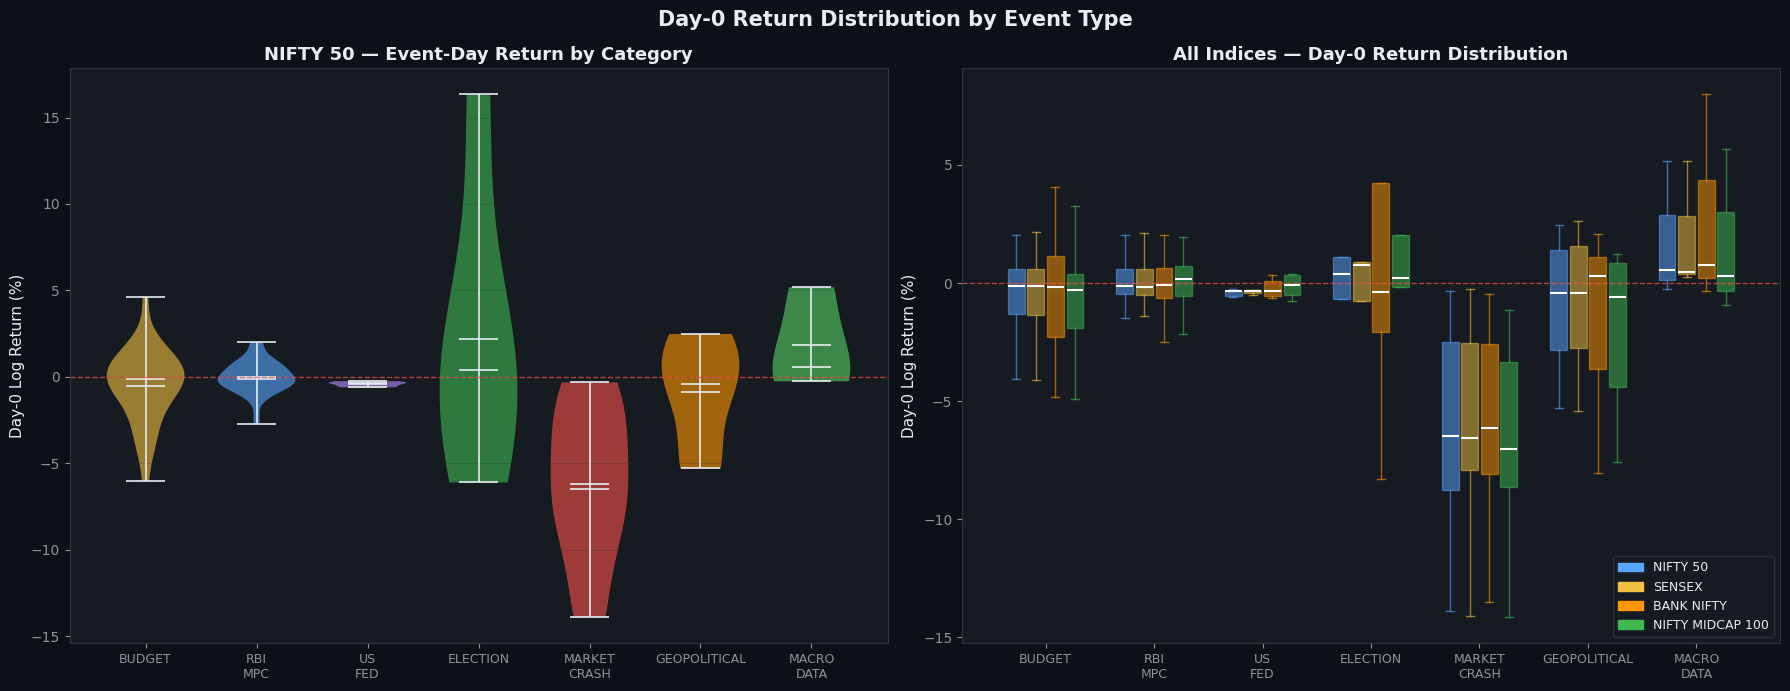

Saved: chart2_day0_distribution.png


In [6]:
# ── CHART 2: Day-0 Return Distribution by Event Type ────────────────────────
day0 = ev_df[ev_df['day_offset'] == 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Day-0 Return Distribution by Event Type', fontsize=15, fontweight='bold')

# Left: violin plot per event type (NIFTY 50 only for clarity)
ax = axes[0]
nifty_day0 = day0[day0['index'] == 'NIFTY 50'].copy()
order = event_types
positions = np.arange(len(order))

violin_data = [nifty_day0[nifty_day0['event_type'] == et]['log_ret'].dropna().values for et in order]
parts = ax.violinplot(violin_data, positions=positions, widths=0.7,
                      showmeans=True, showmedians=True, showextrema=True)

for i, (pc, etype) in enumerate(zip(parts['bodies'], order)):
    pc.set_facecolor(EVENT_COLORS[etype])
    pc.set_alpha(0.6)

for partname in ['cmeans', 'cmedians', 'cbars', 'cmins', 'cmaxes']:
    parts[partname].set_color('#e6edf3')
    parts[partname].set_linewidth(1.2)

ax.set_xticks(positions)
ax.set_xticklabels([e.replace('_', '\n') for e in order], fontsize=9)
ax.axhline(0, color='#f85149', lw=1, ls='--', alpha=0.7)
ax.set_ylabel('Day-0 Log Return (%)')
ax.set_title('NIFTY 50 — Event-Day Return by Category', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# Right: box plots all 4 indices, day-0
ax = axes[1]
index_names = list(INDEX_COLORS.keys())
n_idx = len(index_names)
width = 0.18

for i, idx_name in enumerate(index_names):
    idx_data = day0[day0['index'] == idx_name]
    box_data = [idx_data[idx_data['event_type'] == et]['log_ret'].dropna().values for et in order]
    positions_shifted = np.arange(len(order)) + (i - n_idx/2 + 0.5) * width
    bp = ax.boxplot(box_data, positions=positions_shifted, widths=width * 0.85,
                    patch_artist=True, showfliers=False,
                    medianprops=dict(color='white', linewidth=1.5),
                    whiskerprops=dict(color=INDEX_COLORS[idx_name], alpha=0.6),
                    capprops=dict(color=INDEX_COLORS[idx_name], alpha=0.6),
                    boxprops=dict(facecolor=INDEX_COLORS[idx_name], alpha=0.5,
                                  edgecolor=INDEX_COLORS[idx_name]))

ax.set_xticks(np.arange(len(order)))
ax.set_xticklabels([e.replace('_', '\n') for e in order], fontsize=9)
ax.axhline(0, color='#f85149', lw=1, ls='--', alpha=0.7)
ax.set_ylabel('Day-0 Log Return (%)')
ax.set_title('All Indices — Day-0 Return Distribution', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

legend_handles = [mpatches.Patch(color=c, label=n) for n, c in INDEX_COLORS.items()]
ax.legend(handles=legend_handles, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('chart2_day0_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart2_day0_distribution.png")

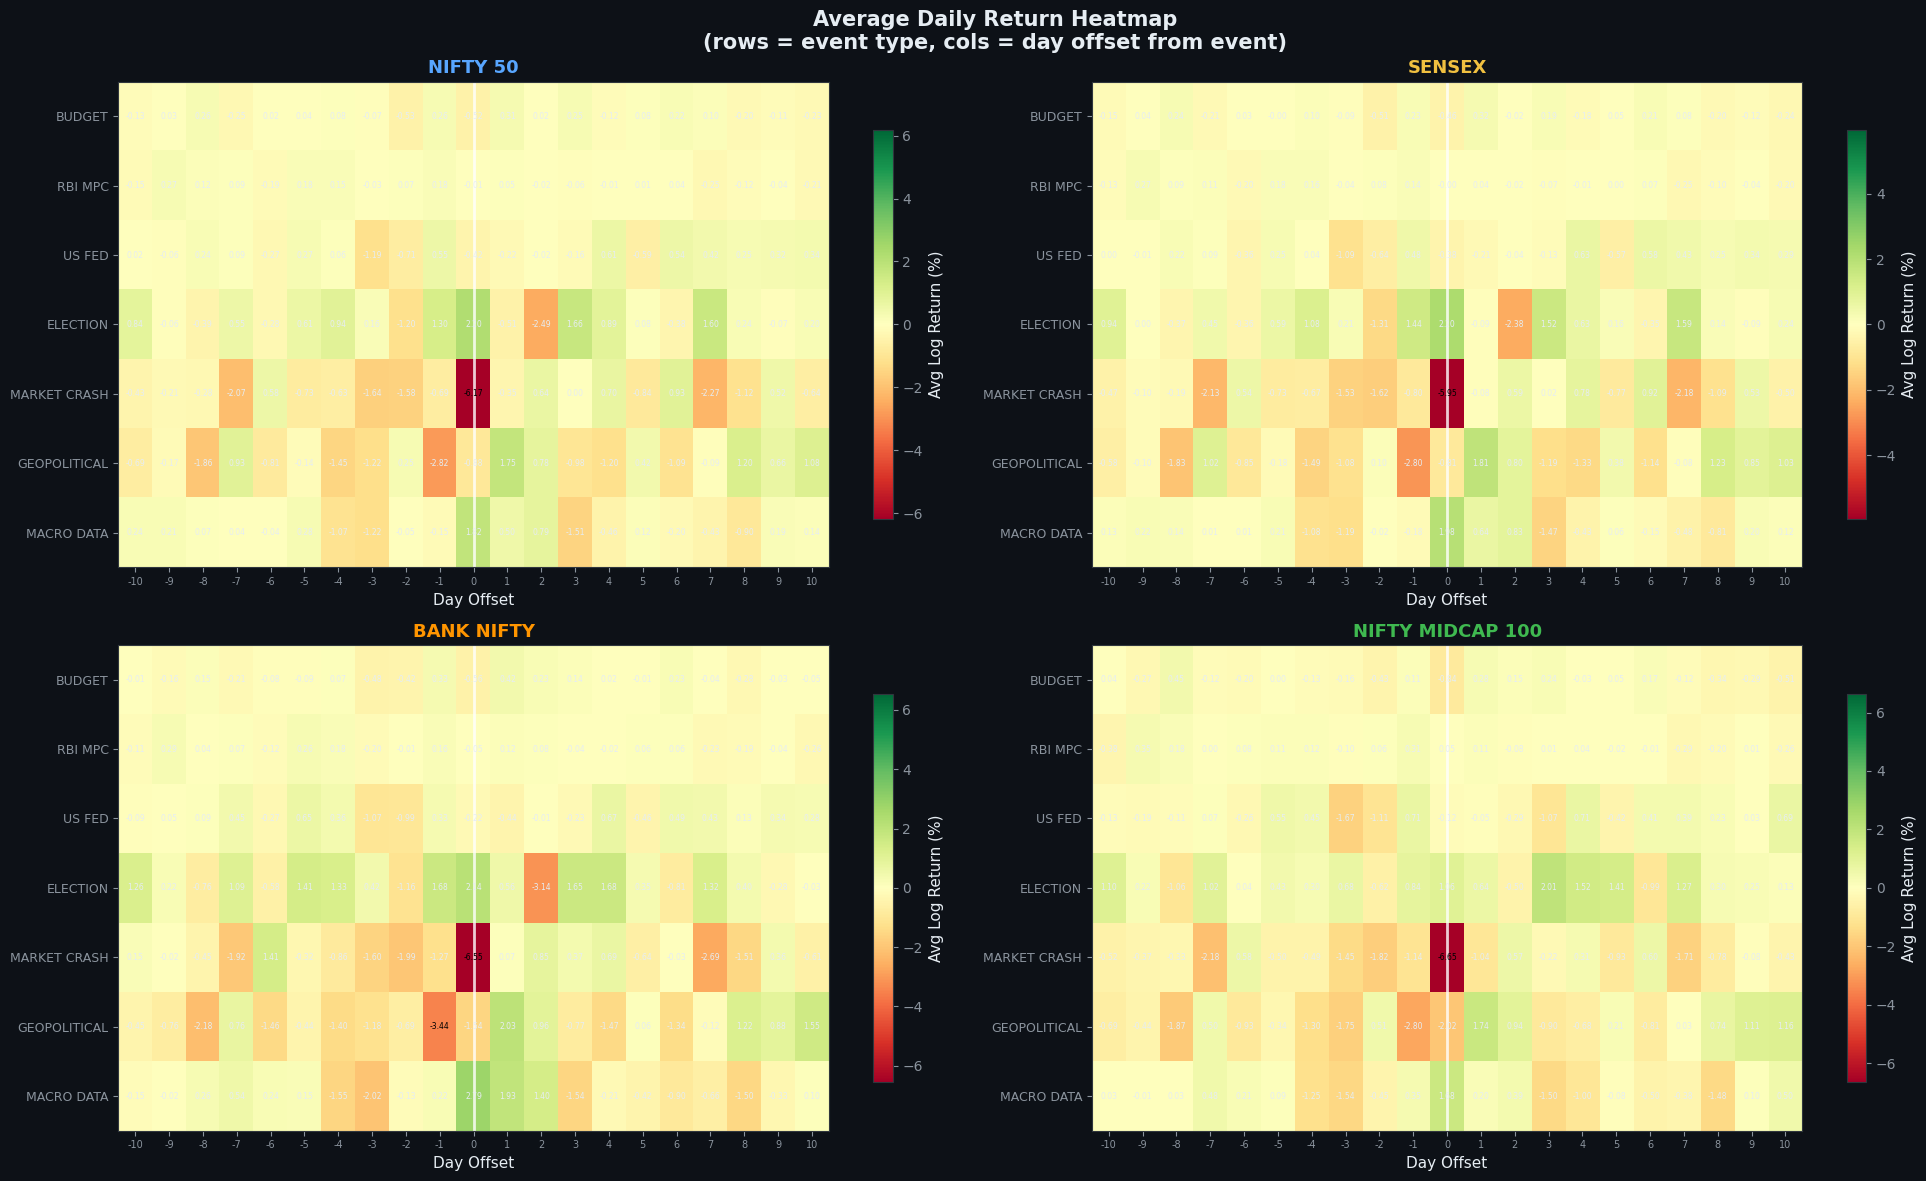

Saved: chart3_heatmap.png


In [7]:
# ── CHART 3: Return Heatmap (Event Type × Day Offset) ───────────────────────
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Average Daily Return Heatmap\n(rows = event type, cols = day offset from event)',
             fontsize=15, fontweight='bold')

for ax, idx_name in zip(axes.flatten(), index_names):
    sub = ev_df[ev_df['index'] == idx_name]
    heat = sub.groupby(['event_type', 'day_offset'])['log_ret'].mean().unstack()
    heat = heat.reindex(event_types)

    vmax = max(abs(heat.values[~np.isnan(heat.values)]).max(), 0.01)

    im = ax.imshow(heat.values, aspect='auto', cmap='RdYlGn',
                   vmin=-vmax, vmax=vmax, interpolation='nearest')

    ax.set_xticks(np.arange(2 * WINDOW + 1))
    ax.set_xticklabels([str(x) for x in range(-WINDOW, WINDOW + 1)], fontsize=7)
    ax.set_yticks(np.arange(len(event_types)))
    ax.set_yticklabels([e.replace('_', ' ') for e in event_types], fontsize=9)
    ax.set_xlabel('Day Offset')
    ax.set_title(idx_name, fontweight='bold', color=INDEX_COLORS[idx_name])

    # annotate cells
    for i in range(len(event_types)):
        for j in range(2 * WINDOW + 1):
            val = heat.values[i, j] if not np.isnan(heat.values[i, j]) else 0
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=5.5, color='black' if abs(val) > vmax * 0.5 else '#e6edf3')

    ax.axvline(WINDOW, color='white', lw=2, alpha=0.8)
    plt.colorbar(im, ax=ax, label='Avg Log Return (%)', shrink=0.8)

plt.tight_layout()
plt.savefig('chart3_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart3_heatmap.png")

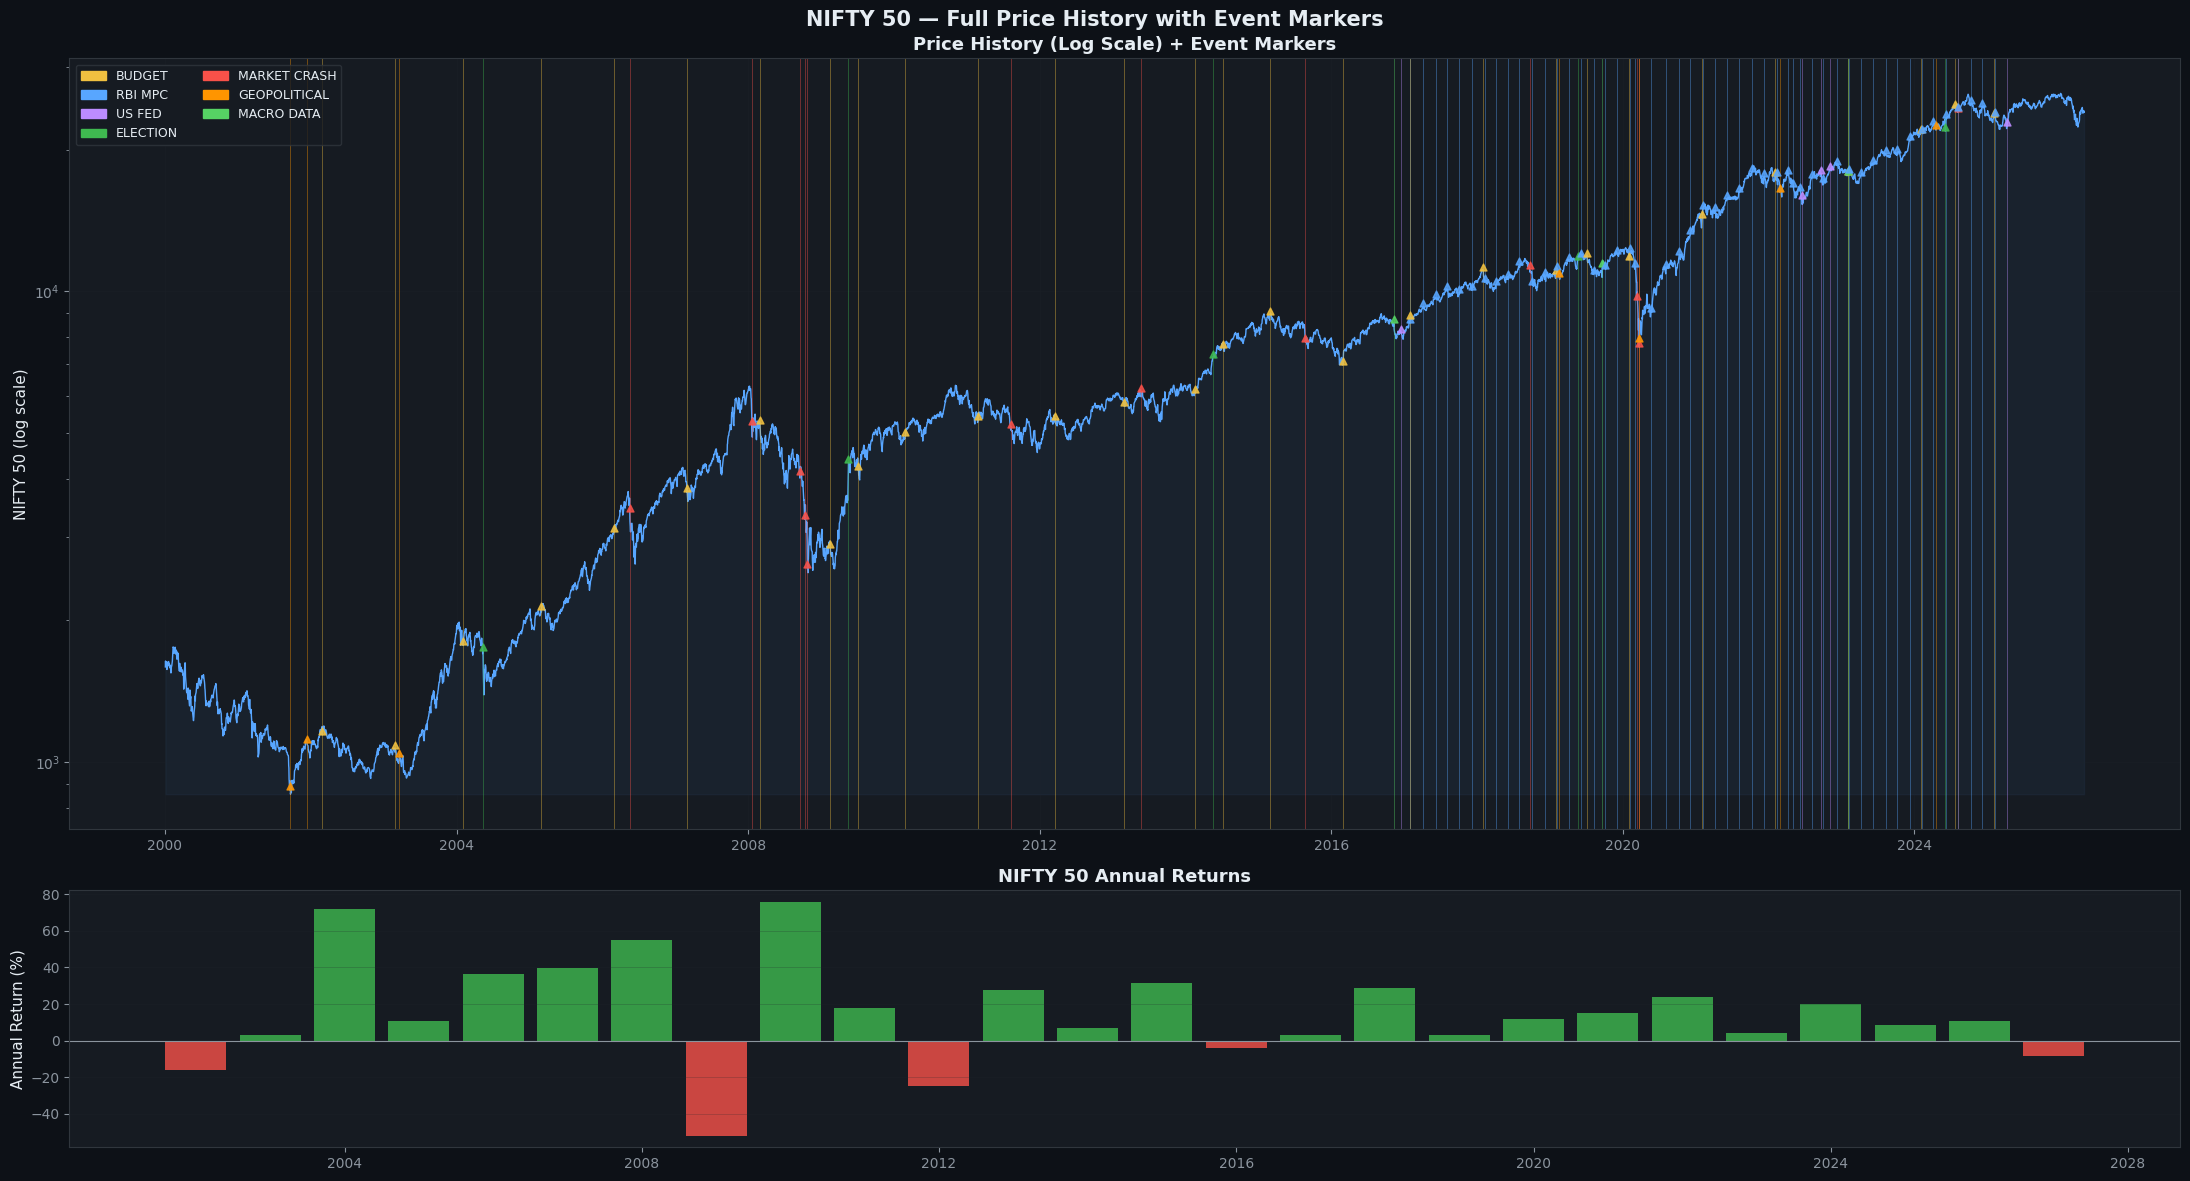

Saved: chart4_timeline.png


In [8]:
# ── CHART 4: NIFTY Price Timeline with Event Markers ───────────────────────
nifty = indices['NIFTY 50'].copy()

fig, axes = plt.subplots(2, 1, figsize=(22, 12), sharex=False,
                          gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle('NIFTY 50 — Full Price History with Event Markers', fontsize=15, fontweight='bold')

ax = axes[0]
ax.plot(nifty.index, nifty['close'], color='#58a6ff', lw=1, label='NIFTY 50 Close')
ax.fill_between(nifty.index, nifty['close'].min(), nifty['close'],
                color='#58a6ff', alpha=0.05)
ax.set_yscale('log')
ax.set_ylabel('NIFTY 50 (log scale)')
ax.grid(True, alpha=0.3)
ax.set_title('Price History (Log Scale) + Event Markers', fontweight='bold')

# overlay event markers
for _, ev in events.iterrows():
    if ev['date'] < nifty.index.min() or ev['date'] > nifty.index.max():
        continue
    try:
        candidates = nifty.index[nifty.index >= ev['date']]
        if len(candidates) == 0:
            continue
        nearest = candidates[0]
        y = nifty.loc[nearest, 'close']
        ax.axvline(ev['date'], color=EVENT_COLORS[ev['event_type']], lw=0.7, alpha=0.4)
        ax.scatter(ev['date'], y * 1.02, color=EVENT_COLORS[ev['event_type']],
                   s=25, zorder=5, alpha=0.85, marker='^')
    except Exception:
        pass

legend_handles = [mpatches.Patch(color=c, label=e.replace('_',' '))
                  for e, c in EVENT_COLORS.items()]
ax.legend(handles=legend_handles, fontsize=9, loc='upper left', ncol=2)

# bottom: annual return bar chart
ax2 = axes[1]
nifty_annual = nifty['close'].resample('YE').last().pct_change() * 100
colors_bar = ['#3fb950' if v > 0 else '#f85149' for v in nifty_annual]
ax2.bar(nifty_annual.index, nifty_annual.values, color=colors_bar, alpha=0.8,
        width=300, label='Annual Return %')
ax2.axhline(0, color='#8b949e', lw=0.8)
ax2.set_ylabel('Annual Return (%)')
ax2.set_title('NIFTY 50 Annual Returns', fontweight='bold')
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('chart4_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart4_timeline.png")

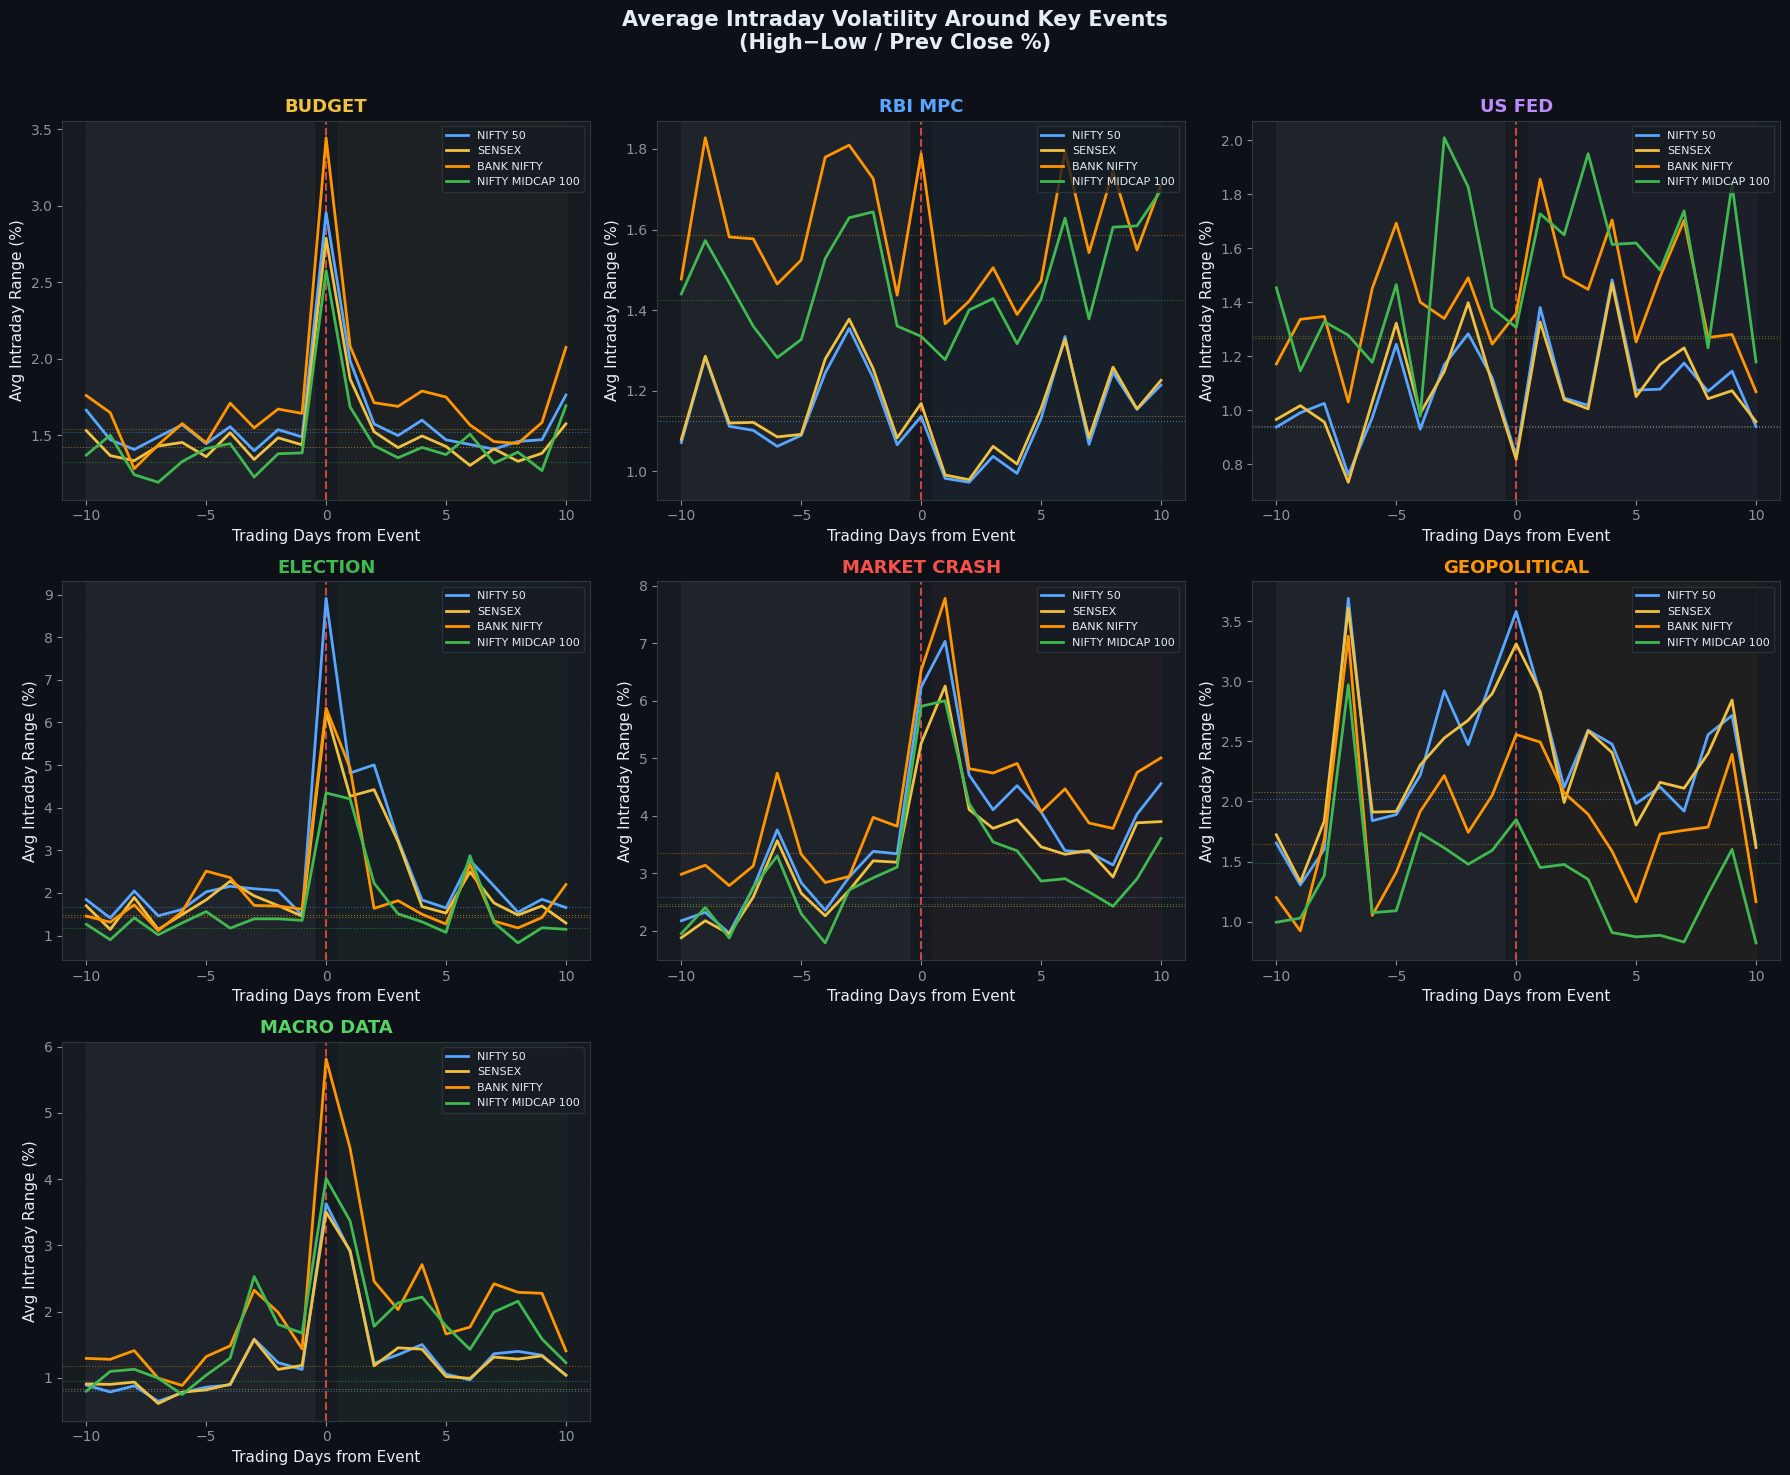

Saved: chart5_volatility_spike.png


In [9]:
# ── CHART 5: Volatility Spike (Intraday Range) Around Events ────────────────
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
fig.suptitle('Average Intraday Volatility Around Key Events\n(High−Low / Prev Close %)',
             fontsize=15, fontweight='bold', y=0.98)
axes = axes.flatten()

for ax_idx, etype in enumerate(event_types):
    ax = axes[ax_idx]
    sub = ev_df[ev_df['event_type'] == etype]

    ax.axvline(0, color='#f85149', lw=1.5, ls='--', alpha=0.8)
    ax.axvspan(-WINDOW, -0.5, alpha=0.04, color='white')
    ax.axvspan(0.5, WINDOW, alpha=0.04, color=EVENT_COLORS[etype])

    for idx_name, idx_color in INDEX_COLORS.items():
        idx_sub = sub[sub['index'] == idx_name]
        if idx_sub.empty:
            continue
        pivot = idx_sub.groupby(['event_date', 'day_offset'])['intraday_range'].first().unstack(level=0)
        mean_vol = pivot.mean(axis=1)
        baseline = pivot.iloc[:5].mean(axis=1).mean()  # pre-event baseline

        ax.plot(mean_vol.index, mean_vol.values, color=idx_color, lw=2,
                label=idx_name, zorder=3)
        if baseline > 0:
            ax.axhline(baseline, color=idx_color, lw=0.8, ls=':', alpha=0.5)

    ax.set_title(f"{etype.replace('_',' ')}",
                 color=EVENT_COLORS[etype], fontweight='bold')
    ax.set_xlabel('Trading Days from Event')
    ax.set_ylabel('Avg Intraday Range (%)')
    ax.set_xticks([-10, -5, 0, 5, 10])
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')

for ax in axes[n_types:]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('chart5_volatility_spike.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart5_volatility_spike.png")

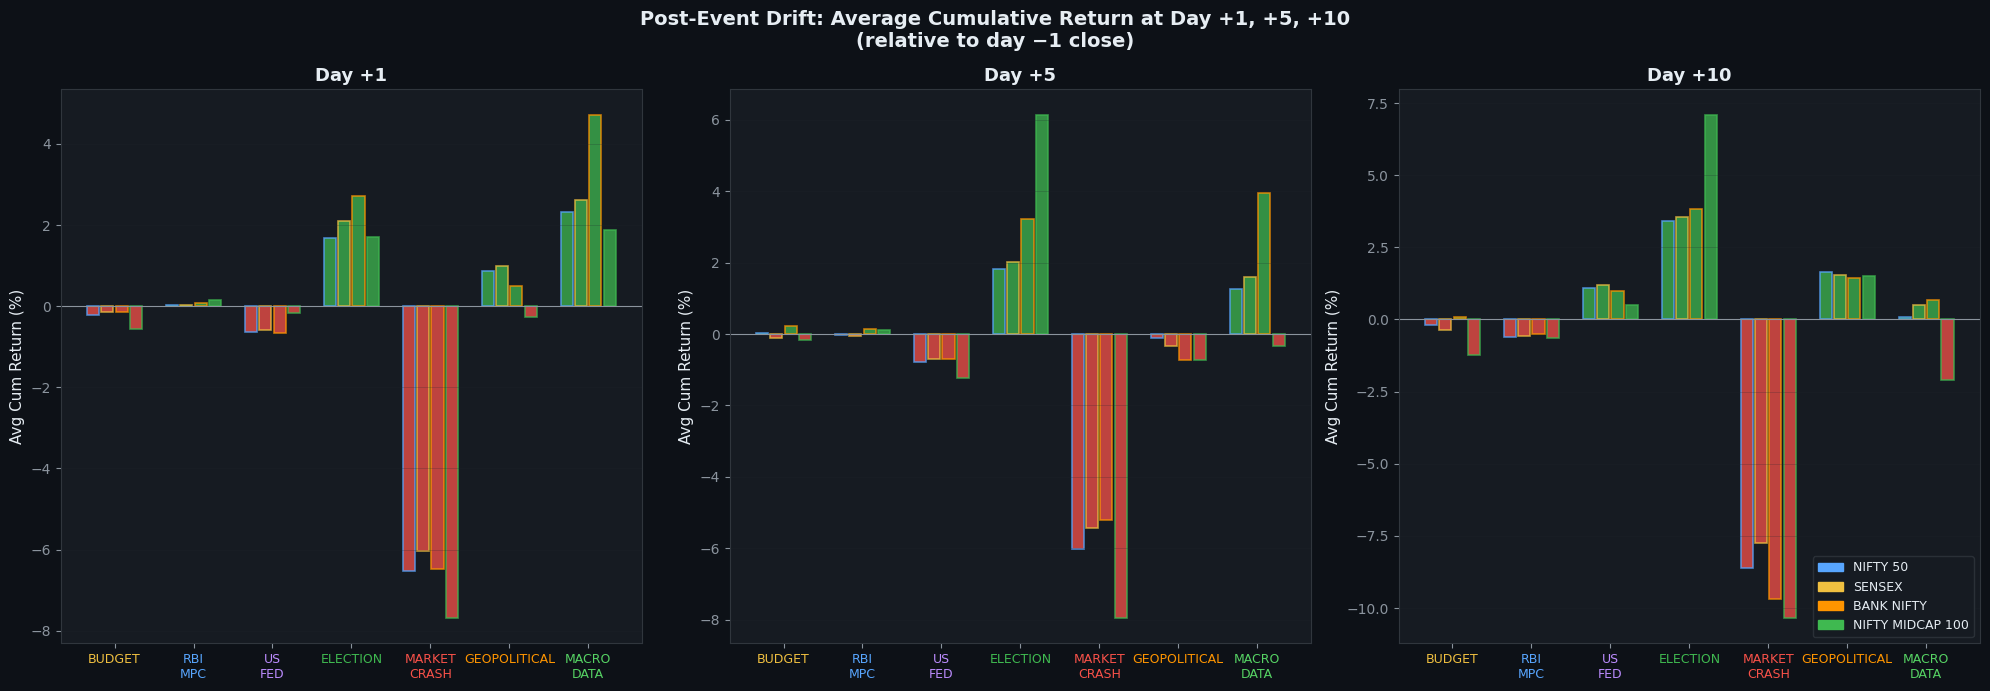

Saved: chart6_post_event_drift.png


In [10]:
# ── CHART 6: Post-Event Drift Summary ────────────────────────────────────────
# For each event type, show avg cumulative return at day +1, +5, +10

checkpoints = [1, 5, 10]
drift_records = []

for etype in event_types:
    for idx_name in index_names:
        sub = ev_df[(ev_df['event_type'] == etype) & (ev_df['index'] == idx_name)]
        if sub.empty:
            continue
        for cp in checkpoints:
            cp_sub = sub[sub['day_offset'] == cp]['cum_ret']
            if len(cp_sub) < 2:
                continue
            drift_records.append({
                'event_type': etype,
                'index': idx_name,
                'day': cp,
                'mean_cum_ret': cp_sub.mean(),
                'n': len(cp_sub),
            })

drift_df = pd.DataFrame(drift_records)

fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=False)
fig.suptitle('Post-Event Drift: Average Cumulative Return at Day +1, +5, +10\n(relative to day −1 close)',
             fontsize=14, fontweight='bold')

for ax, cp in zip(axes, checkpoints):
    cp_df = drift_df[drift_df['day'] == cp]

    x = np.arange(len(event_types))
    n_idx = len(index_names)
    w = 0.18

    for i, idx_name in enumerate(index_names):
        vals = [cp_df[(cp_df['event_type'] == et) & (cp_df['index'] == idx_name)]['mean_cum_ret'].values
                for et in event_types]
        vals = [v[0] if len(v) > 0 else 0 for v in vals]
        positions = x + (i - n_idx/2 + 0.5) * w
        bar_colors = ['#3fb950' if v > 0 else '#f85149' for v in vals]
        ax.bar(positions, vals, width=w * 0.85,
               color=bar_colors, alpha=0.75,
               edgecolor=INDEX_COLORS[idx_name], linewidth=1.2,
               label=idx_name)

    ax.axhline(0, color='#8b949e', lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([e.replace('_', '\n') for e in event_types], fontsize=9)
    ax.set_title(f'Day +{cp}', fontweight='bold', fontsize=13)
    ax.set_ylabel('Avg Cum Return (%)')
    ax.grid(True, axis='y', alpha=0.3)

    # event-type color dots on x-axis
    for tick, etype in zip(ax.get_xticklabels(), event_types):
        tick.set_color(EVENT_COLORS[etype])

legend_handles = [mpatches.Patch(color=c, label=n) for n, c in INDEX_COLORS.items()]
axes[-1].legend(handles=legend_handles, fontsize=9, loc='lower right')

plt.tight_layout()
plt.savefig('chart6_post_event_drift.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart6_post_event_drift.png")

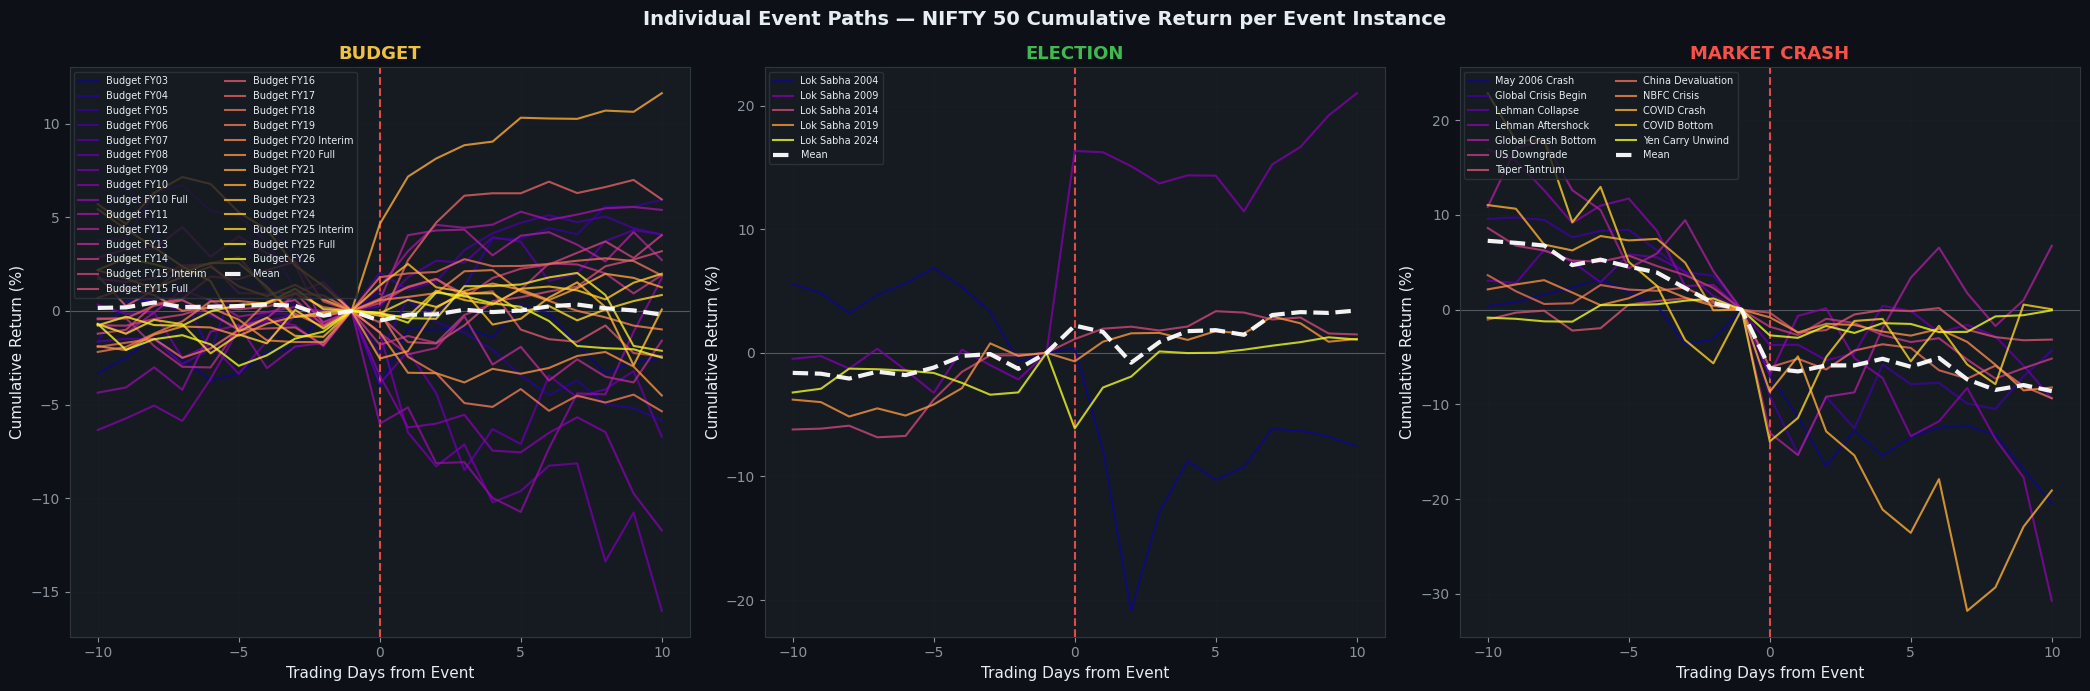

Saved: chart7_individual_events.png


In [11]:
# ── CHART 7: Individual Event Deep-Dive — all events on one NIFTY chart ─────
# For a selected event type, show each individual event's path
target_types = ['BUDGET', 'ELECTION', 'MARKET_CRASH']

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.suptitle('Individual Event Paths — NIFTY 50 Cumulative Return per Event Instance',
             fontsize=14, fontweight='bold')

for ax, etype in zip(axes, target_types):
    sub = ev_df[(ev_df['event_type'] == etype) & (ev_df['index'] == 'NIFTY 50')]
    events_in_type = sub['event_date'].unique()

    cmap = plt.cm.plasma
    n_ev = len(events_in_type)

    ax.axvline(0, color='#f85149', lw=1.5, ls='--', alpha=0.9)
    ax.axhline(0, color='#8b949e', lw=0.8, alpha=0.5)

    for j, edate in enumerate(sorted(events_in_type)):
        ev_data = sub[sub['event_date'] == edate].sort_values('day_offset')
        label_row = events[events['date'] == edate]
        lbl = label_row['label'].values[0] if len(label_row) > 0 else str(edate.date())
        color = cmap(j / max(n_ev - 1, 1))
        ax.plot(ev_data['day_offset'], ev_data['cum_ret'],
                color=color, lw=1.5, alpha=0.8, label=lbl)

    # mean line
    pivot = sub.groupby(['event_date', 'day_offset'])['cum_ret'].first().unstack(level=0)
    mean_line = pivot.mean(axis=1)
    ax.plot(mean_line.index, mean_line.values, color='white', lw=3,
            ls='--', alpha=0.95, label='Mean', zorder=10)

    ax.set_title(etype.replace('_', ' '), color=EVENT_COLORS[etype], fontweight='bold')
    ax.set_xlabel('Trading Days from Event')
    ax.set_ylabel('Cumulative Return (%)')
    ax.set_xticks([-10, -5, 0, 5, 10])
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='upper left', ncol=2 if n_ev > 8 else 1)

plt.tight_layout()
plt.savefig('chart7_individual_events.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart7_individual_events.png")

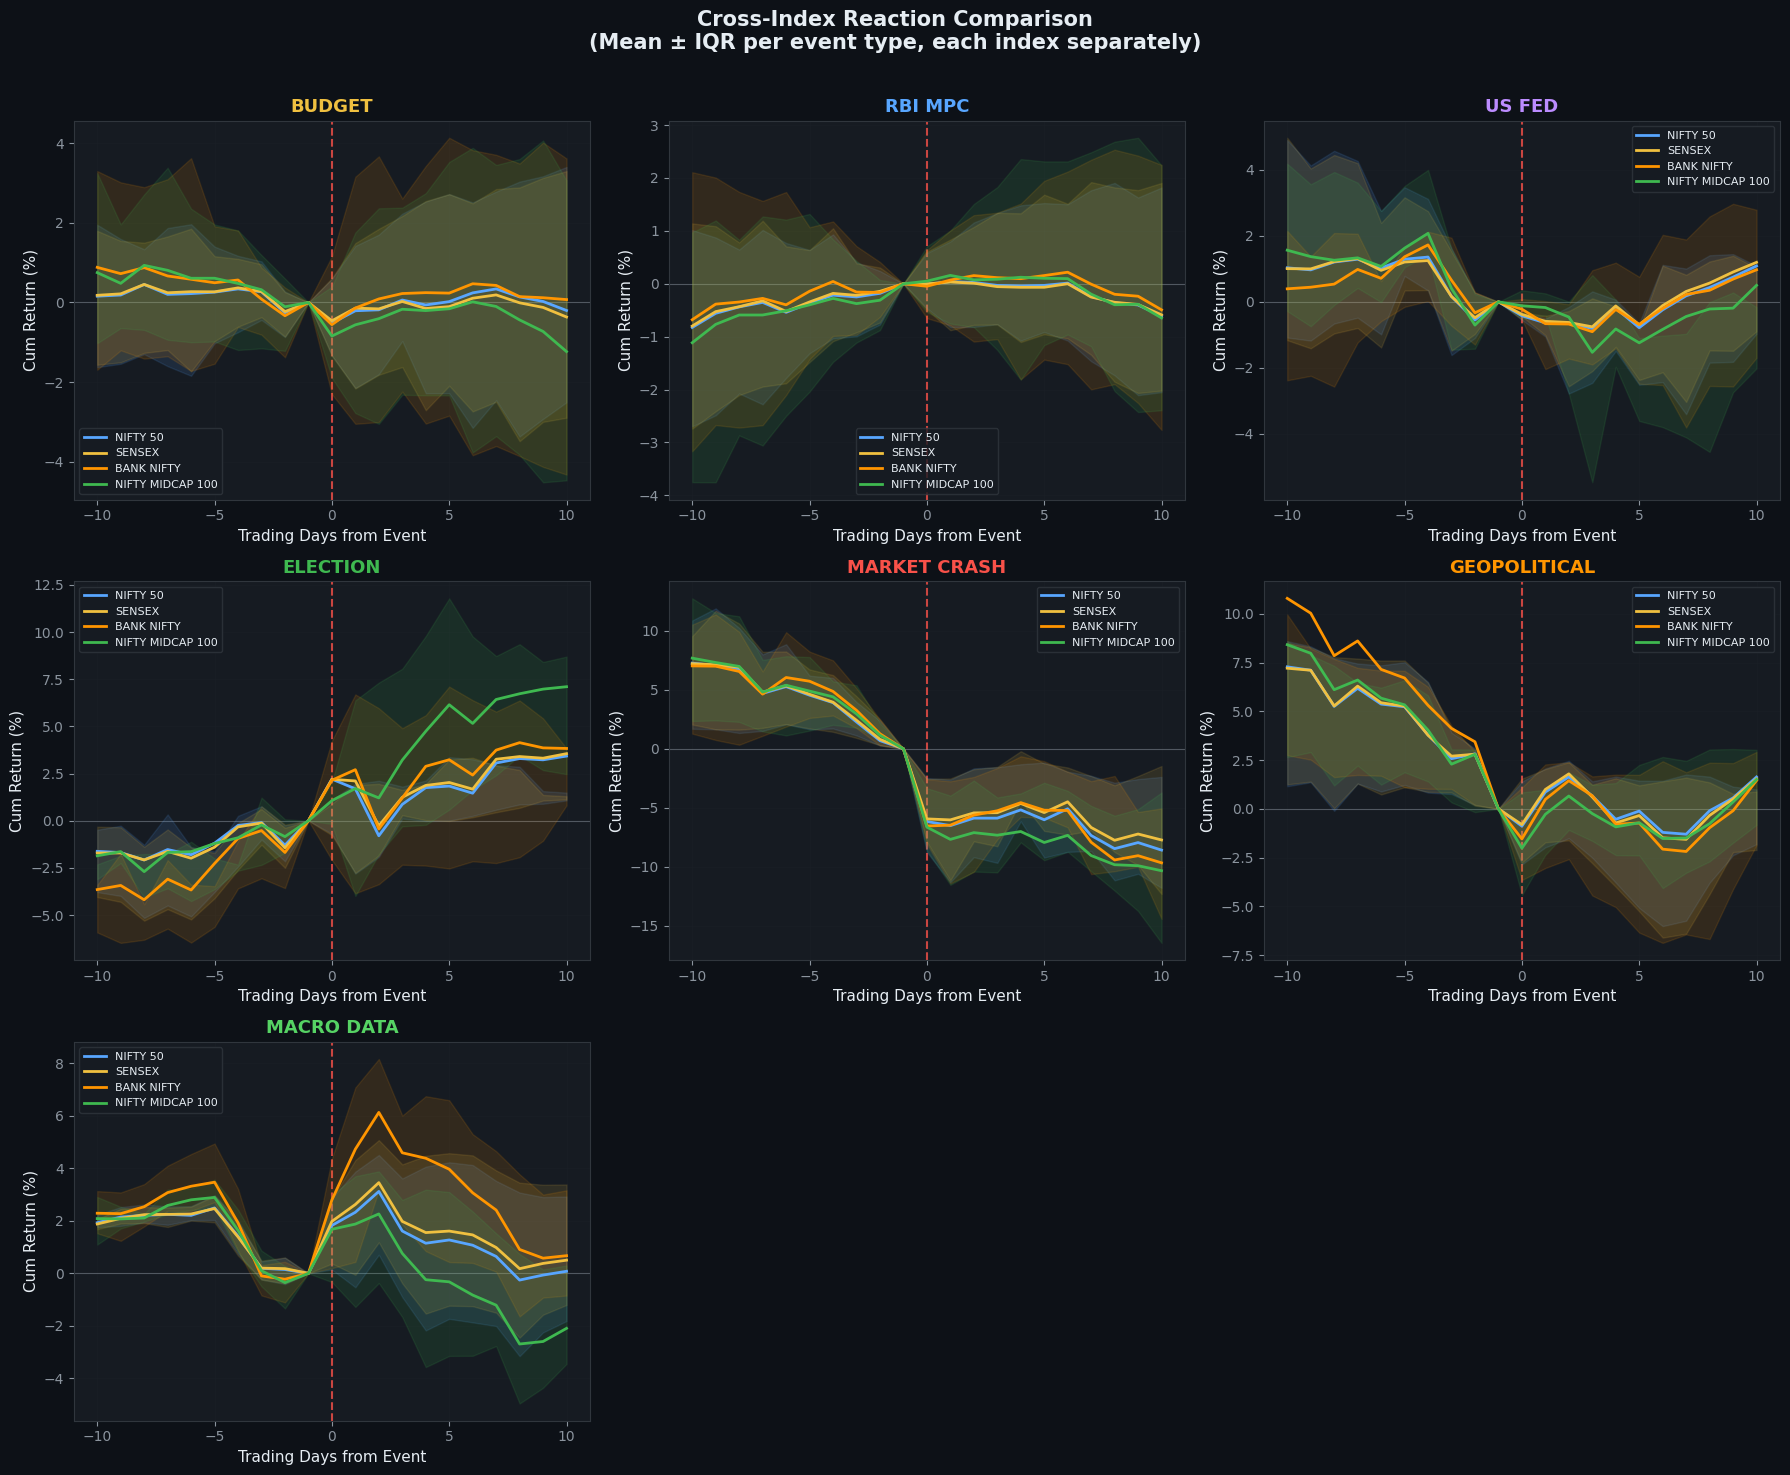

Saved: chart8_cross_index.png


In [12]:
# ── CHART 8: Cross-Index Comparison — same event type, all 4 indices ────────
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
fig.suptitle('Cross-Index Reaction Comparison\n(Mean ± IQR per event type, each index separately)',
             fontsize=15, fontweight='bold', y=0.98)
axes = axes.flatten()

for ax_idx, etype in enumerate(event_types):
    ax = axes[ax_idx]
    sub = ev_df[ev_df['event_type'] == etype]

    ax.axvline(0, color='#f85149', lw=1.5, ls='--', alpha=0.8)
    ax.axhline(0, color='#8b949e', lw=0.8, alpha=0.5)

    for idx_name, idx_color in INDEX_COLORS.items():
        idx_sub = sub[sub['index'] == idx_name]
        if idx_sub.empty:
            continue
        g = idx_sub.groupby('day_offset')['cum_ret']
        mean_r = g.mean()
        p25 = g.quantile(0.25)
        p75 = g.quantile(0.75)

        ax.plot(mean_r.index, mean_r.values, color=idx_color, lw=2,
                label=idx_name, zorder=3)
        ax.fill_between(mean_r.index, p25.values, p75.values,
                        color=idx_color, alpha=0.12, zorder=2)

    ax.set_title(etype.replace('_', ' '), color=EVENT_COLORS[etype], fontweight='bold')
    ax.set_xlabel('Trading Days from Event')
    ax.set_ylabel('Cum Return (%)')
    ax.set_xticks([-10, -5, 0, 5, 10])
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes[n_types:]:
    ax.set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('chart8_cross_index.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: chart8_cross_index.png")

In [13]:
# ── SUMMARY TABLE ─────────────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("EVENT REACTION SUMMARY — NIFTY 50")
print("=" * 80)

nifty_ev = ev_df[ev_df['index'] == 'NIFTY 50']

summary_rows = []
for etype in event_types:
    sub = nifty_ev[nifty_ev['event_type'] == etype]
    if sub.empty:
        continue
    n_ev = sub['event_date'].nunique()

    day_m1  = sub[sub['day_offset'] == -1]['cum_ret'].mean()
    day_0   = sub[sub['day_offset'] == 0]['log_ret'].mean()
    day_p1  = sub[sub['day_offset'] == 1]['cum_ret'].mean()
    day_p5  = sub[sub['day_offset'] == 5]['cum_ret'].mean()
    day_p10 = sub[sub['day_offset'] == 10]['cum_ret'].mean()
    vol_d0  = sub[sub['day_offset'] == 0]['intraday_range'].mean()
    vol_base = sub[sub['day_offset'] == -5]['intraday_range'].mean()

    summary_rows.append({
        'Event Type':       etype.replace('_', ' '),
        'N Events':         n_ev,
        'Day-1 Cum Ret%':   round(day_m1,  2),
        'Day-0 Return%':    round(day_0,   2),
        'Day+1 Cum Ret%':   round(day_p1,  2),
        'Day+5 Cum Ret%':   round(day_p5,  2),
        'Day+10 Cum Ret%':  round(day_p10, 2),
        'D0 Vol% (range)':  round(vol_d0,  2),
        'Base Vol% (D-5)':  round(vol_base, 2),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Event Type')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', lambda x: f'{x:+.2f}')
print(summary_df.to_string())
print()

# Key insights
best_day0 = summary_df['Day-0 Return%'].idxmax()
worst_day0 = summary_df['Day-0 Return%'].idxmin()
most_vol = summary_df['D0 Vol% (range)'].idxmax()
best_drift = summary_df['Day+10 Cum Ret%'].idxmax()
worst_drift = summary_df['Day+10 Cum Ret%'].idxmin()

print("KEY INSIGHTS (NIFTY 50):")
print(f"  Strongest avg day-0 pop  : {best_day0}")
print(f"  Worst avg day-0 drop     : {worst_day0}")
print(f"  Highest day-0 volatility : {most_vol}")
print(f"  Best +10d drift          : {best_drift}")
print(f"  Worst +10d drift         : {worst_drift}")


EVENT REACTION SUMMARY — NIFTY 50
              N Events  Day-1 Cum Ret%  Day-0 Return%  Day+1 Cum Ret%  Day+5 Cum Ret%  Day+10 Cum Ret%  D0 Vol% (range)  Base Vol% (D-5)
Event Type                                                                                                                              
BUDGET              28           +0.00          -0.52           -0.21           +0.02            -0.20            +2.95            +1.45
RBI MPC             50           +0.00          -0.01           +0.04           -0.03            -0.61            +1.14            +1.09
US FED               5           +0.00          -0.42           -0.64           -0.78            +1.09            +0.83            +1.24
ELECTION             5           +0.00          +2.20           +1.69           +1.83            +3.43            +8.91            +2.03
MARKET CRASH        12           +0.00          -6.17           -6.52           -6.03            -8.60            +6.24            +2.84
GEOPOL